In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False

import sys
import numpy as np
import torch
import rasterio
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import matplotlib.colors as mcolors

# 路径
DATA_DIR      = Path(r'D:\geology AI\data\raw\hls_sample')
CLAY_MODEL_DIR = Path(r'D:\geology AI\clay-model')
CLAY_CKPT     = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\clay\v1.5\clay-v1.5.ckpt')
FIG_DIR       = Path(r'D:\geology AI\results\figures')

sys.path.insert(0, str(CLAY_MODEL_DIR))
from claymodel.model import Encoder

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BANDS  = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']
WAVES  = torch.tensor([0.49, 0.56, 0.665, 0.865, 1.61, 2.19], dtype=torch.float32)

print(f'设备: {DEVICE}')
print(f'所有路径检查:')
for p in [DATA_DIR, CLAY_MODEL_DIR, CLAY_CKPT]:
    print(f'  {"✓" if p.exists() else "✗"} {p.name}')

c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


设备: cuda
所有路径检查:
  ✓ hls_sample
  ✓ clay-model
  ✓ clay-v1.5.ckpt


In [2]:
# 加载 Clay Encoder（与 Day 1 完全相同）
ckpt = torch.load(CLAY_CKPT, map_location='cpu', weights_only=False)
state_dict = ckpt['state_dict']

encoder_state_dict = {
    k.replace('model.encoder.', ''): v
    for k, v in state_dict.items()
    if k.startswith('model.encoder.')
}

encoder = Encoder(
    mask_ratio=0.0,
    patch_size=8,
    shuffle=False,
    dim=1024,
    depth=24,
    heads=16,
    dim_head=64,
    mlp_ratio=4,
)
encoder.load_state_dict(encoder_state_dict, strict=False)
encoder = encoder.to(DEVICE).eval()
print(f'✓ Clay Encoder 加载成功  参数量: {sum(p.numel() for p in encoder.parameters())/1e6:.1f}M')

✓ Clay Encoder 加载成功  参数量: 311.4M


In [3]:
# 读取全幅影像
def read_band(band_name):
    with rasterio.open(DATA_DIR / f'{band_name}.tif') as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = 0.0
    return arr

print('读取全幅影像...')
full_img = np.stack([read_band(b) for b in BANDS], axis=0)  # (6, H, W)
H, W = full_img.shape[1], full_img.shape[2]
print(f'全幅影像形状: {full_img.shape}  ({H}×{W})')

# 定义 patch embedding 提取函数
def extract_embedding(img_patch):
    """
    img_patch: (6, 256, 256) numpy array，原始 DN 值
    返回: (1024,) embedding 向量
    """
    pixels = torch.tensor(img_patch, dtype=torch.float32).unsqueeze(0)  # (1,6,256,256)
    # 归一化到 0~1
    for i in range(6):
        p2, p98 = np.percentile(img_patch[i], [2, 98])
        pixels[0, i] = torch.clamp(
            (pixels[0, i] - p2) / (p98 - p2 + 1e-8), 0, 1)

    datacube = {
        'pixels': pixels.to(DEVICE),
        'time':   torch.zeros(1, 4).to(DEVICE),
        'latlon': torch.tensor([[-33.87, 151.21, -33.87, 151.21]]).to(DEVICE),
        'gsd':    torch.tensor(30.0).to(DEVICE),
        'waves':  WAVES.to(DEVICE),
    }

    with torch.no_grad():
        output = encoder(datacube)

    # unmasked_patches[0, 0] = CLS token
    cls_emb = output[0][0, 0, :].cpu().numpy()   # (1024,)
    return cls_emb

# 测试一次
test_patch = full_img[:, H//2-128:H//2+128, W//2-128:W//2+128]
test_emb   = extract_embedding(test_patch)
print(f'\n✓ 单次 embedding 提取成功  shape={test_emb.shape}')
print(f'  范围: [{test_emb.min():.3f}, {test_emb.max():.3f}]')

读取全幅影像...
全幅影像形状: (6, 3660, 3660)  (3660×3660)

✓ 单次 embedding 提取成功  shape=(1024,)
  范围: [-1.319, 0.550]


In [4]:
# ── 三类地物定义（基于 NDVI/NDWI 自动采样）────────────────────
eps = 1e-6
nir   = full_img[3]; red   = full_img[2]
green = full_img[1]

ndvi = (nir - red)   / (nir + red   + eps)
ndwi = (green - nir) / (green + nir + eps)

# 三类掩码
vegetation_map = (ndvi > 0.35).astype(np.uint8)   # 健康植被
bare_map       = ((ndvi < 0.15) & (ndwi < 0.0)).astype(np.uint8)  # 裸土
water_map      = (ndwi > 0.2).astype(np.uint8)    # 水体

print('各类别全图覆盖率:')
print(f'  植被 (NDVI>0.35):  {vegetation_map.mean():.3f}')
print(f'  裸土 (NDVI<0.15):  {bare_map.mean():.3f}')
print(f'  水体 (NDWI>0.20):  {water_map.mean():.3f}')

# 采样函数：在满足条件的区域随机采样 patch
P = 256  # patch 尺寸

def sample_patches(class_map, n_samples=20, seed=42):
    """在 class_map 高覆盖区域随机采样 patch"""
    np.random.seed(seed)
    patches, coords = [], []
    tried = 0
    while len(patches) < n_samples and tried < n_samples * 50:
        tried += 1
        y0 = np.random.randint(0, H - P)
        x0 = np.random.randint(0, W - P)
        patch_mask = class_map[y0:y0+P, x0:x0+P]
        if patch_mask.mean() > 0.6:   # patch 内 60% 以上属于该类别
            patches.append(full_img[:, y0:y0+P, x0:x0+P].copy())
            coords.append((y0, x0))
    print(f'  采样 {len(patches)} 个（尝试 {tried} 次）')
    return patches, coords

print('\n采样各类 patch:')
print('植被:', end=' '); veg_patches,  veg_coords  = sample_patches(vegetation_map, 20, seed=0)
print('裸土:', end=' '); bare_patches, bare_coords = sample_patches(bare_map,       20, seed=1)
print('水体:', end=' '); wat_patches,  wat_coords  = sample_patches(water_map,      20, seed=2)

各类别全图覆盖率:
  植被 (NDVI>0.35):  0.554
  裸土 (NDVI<0.15):  0.140
  水体 (NDWI>0.20):  0.047

采样各类 patch:
植被:   采样 20 个（尝试 48 次）
裸土:   采样 18 个（尝试 1000 次）
水体:   采样 0 个（尝试 1000 次）


In [5]:
# 调整阈值重新采样
vegetation_map = (ndvi > 0.35).astype(np.uint8)
bare_map       = ((ndvi < 0.20) & (ndwi < 0.0)).astype(np.uint8)
water_map      = (ndwi > 0.10).astype(np.uint8)   # 降低水体阈值

print('调整后各类别覆盖率:')
print(f'  植被 (NDVI>0.35):  {vegetation_map.mean():.3f}')
print(f'  裸土 (NDVI<0.20):  {bare_map.mean():.3f}')
print(f'  水体 (NDWI>0.10):  {water_map.mean():.3f}')

# patch 内纯度要求也降低
def sample_patches(class_map, n_samples=20, seed=42, purity=0.5):
    np.random.seed(seed)
    patches, coords = [], []
    tried = 0
    while len(patches) < n_samples and tried < n_samples * 100:
        tried += 1
        y0 = np.random.randint(0, H - P)
        x0 = np.random.randint(0, W - P)
        patch_mask = class_map[y0:y0+P, x0:x0+P]
        if patch_mask.mean() > purity:
            patches.append(full_img[:, y0:y0+P, x0:x0+P].copy())
            coords.append((y0, x0))
    print(f'  采样 {len(patches)} 个（尝试 {tried} 次）')
    return patches, coords

print('\n重新采样:')
print('植被:', end=' '); veg_patches,  veg_coords  = sample_patches(vegetation_map, 20, seed=0, purity=0.6)
print('裸土:', end=' '); bare_patches, bare_coords = sample_patches(bare_map,       20, seed=1, purity=0.4)
print('水体:', end=' '); wat_patches,  wat_coords  = sample_patches(water_map,      20, seed=2, purity=0.3)

调整后各类别覆盖率:
  植被 (NDVI>0.35):  0.554
  裸土 (NDVI<0.20):  0.189
  水体 (NDWI>0.10):  0.064

重新采样:
植被:   采样 20 个（尝试 48 次）
裸土:   采样 20 个（尝试 141 次）
水体:   采样 20 个（尝试 199 次）


In [6]:
from tqdm import tqdm

def extract_all_embeddings(patches, label, label_id):
    embeddings = []
    labels = []
    print(f'提取 {label} embedding...')
    for patch in tqdm(patches, desc=label):
        emb = extract_embedding(patch)
        embeddings.append(emb)
        labels.append(label_id)
    return embeddings, labels

# 提取三类 embedding
veg_embs,  veg_labels  = extract_all_embeddings(veg_patches,  '植被', 0)
bare_embs, bare_labels = extract_all_embeddings(bare_patches, '裸土', 1)
wat_embs,  wat_labels  = extract_all_embeddings(wat_patches,  '水体', 2)

# 合并
all_embs   = np.array(veg_embs + bare_embs + wat_embs)   # (60, 1024)
all_labels = np.array(veg_labels + bare_labels + wat_labels)  # (60,)

print(f'\n✓ 全部提取完成')
print(f'  embedding 矩阵: {all_embs.shape}')
print(f'  标签分布: 植被={sum(all_labels==0)} 裸土={sum(all_labels==1)} 水体={sum(all_labels==2)}')

提取 植被 embedding...


植被: 100%|██████████| 20/20 [00:01<00:00, 15.58it/s]


提取 裸土 embedding...


裸土: 100%|██████████| 20/20 [00:01<00:00, 19.25it/s]


提取 水体 embedding...


水体: 100%|██████████| 20/20 [00:01<00:00, 19.29it/s]


✓ 全部提取完成
  embedding 矩阵: (60, 1024)
  标签分布: 植被=20 裸土=20 水体=20


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Few-shot 实验：只用 N 个样本训练，其余测试 ────────────────
CLASS_NAMES = ['植被', '裸土', '水体']

results = {}
for n_shot in [3, 5, 10]:
    # 每类取 n_shot 个作为训练，其余作为测试
    train_idx, test_idx = [], []
    for cls_id in range(3):
        cls_indices = np.where(all_labels == cls_id)[0]
        train_idx.extend(cls_indices[:n_shot])
        test_idx.extend(cls_indices[n_shot:])

    X_train = all_embs[train_idx]
    y_train = all_labels[train_idx]
    X_test  = all_embs[test_idx]
    y_test  = all_labels[test_idx]

    # KNN 分类器（k=1，最近邻）
    knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
    knn.fit(X_train, y_train)
    knn_acc = knn.score(X_test, y_test)

    # 线性分类器
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_acc = lr.score(X_test, y_test)

    results[n_shot] = {'knn': knn_acc, 'lr': lr_acc,
                       'knn_model': knn, 'lr_model': lr,
                       'X_test': X_test, 'y_test': y_test}
    print(f'{n_shot}-shot:  KNN={knn_acc:.3f}  LinearProbe={lr_acc:.3f}')

print('\n最佳配置（10-shot Linear）详细报告:')
best = results[10]
y_pred = best['lr_model'].predict(best['X_test'])
print(classification_report(best['y_test'], y_pred, target_names=CLASS_NAMES))


3-shot:  KNN=0.784  LinearProbe=0.745
5-shot:  KNN=0.844  LinearProbe=0.667
10-shot:  KNN=0.900  LinearProbe=0.700

最佳配置（10-shot Linear）详细报告:
              precision    recall  f1-score   support

          植被       0.73      0.80      0.76        10
          裸土       0.64      0.90      0.75        10
          水体       0.80      0.40      0.53        10

    accuracy                           0.70        30
   macro avg       0.72      0.70      0.68        30
weighted avg       0.72      0.70      0.68        30



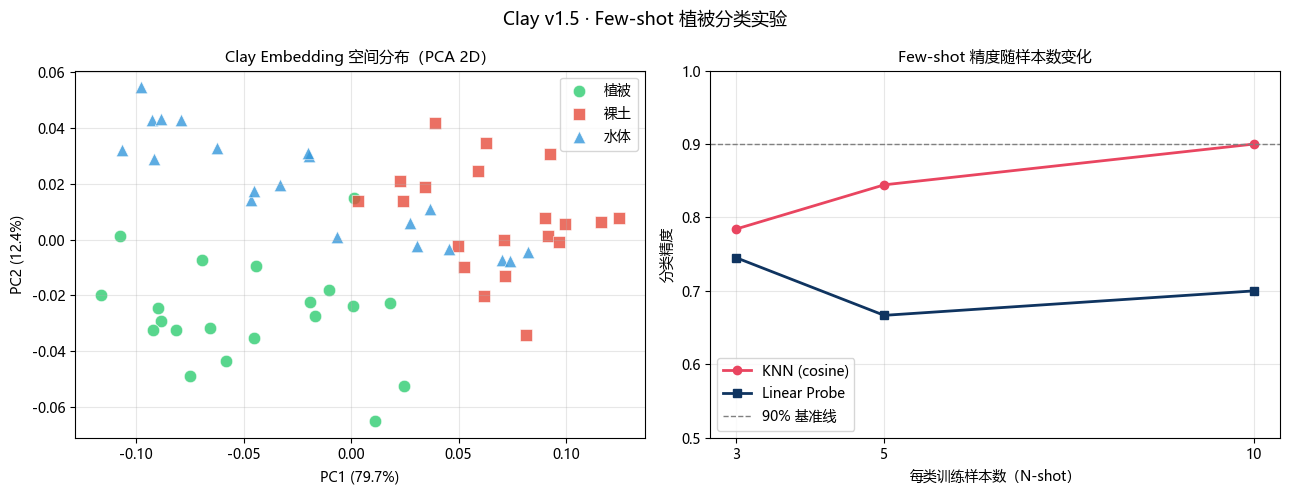

图已保存


In [8]:
# PCA 降维可视化 embedding 空间
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embs_2d = pca.fit_transform(all_embs)  # (60, 2)

colors = ['#2ecc71', '#e74c3c', '#3498db']
markers = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：PCA 散点图
for cls_id, (name, color, marker) in enumerate(zip(CLASS_NAMES, colors, markers)):
    idx = all_labels == cls_id
    axes[0].scatter(embs_2d[idx, 0], embs_2d[idx, 1],
                    c=color, marker=marker, s=80,
                    label=name, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[0].set_title('Clay Embedding 空间分布（PCA 2D）', fontsize=11)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 右图：Few-shot 精度随样本数变化
n_shots = [3, 5, 10]
knn_accs = [results[n]['knn'] for n in n_shots]
lr_accs  = [results[n]['lr']  for n in n_shots]

axes[1].plot(n_shots, knn_accs, 'o-', color='#e94560', lw=2, label='KNN (cosine)')
axes[1].plot(n_shots, lr_accs,  's-', color='#0f3460', lw=2, label='Linear Probe')
axes[1].axhline(0.9, color='gray', ls='--', lw=1, label='90% 基准线')
axes[1].set_xlabel('每类训练样本数（N-shot）')
axes[1].set_ylabel('分类精度')
axes[1].set_title('Few-shot 精度随样本数变化', fontsize=11)
axes[1].set_xticks(n_shots)
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Clay v1.5 · Few-shot 植被分类实验', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_11_fewshot_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

In [9]:
import subprocess, os

REPO_DIR = r'D:\geology AI'
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)

git('git add notebooks/11_clay_fewshot.ipynb')
git('git add results/figures/week3_11_fewshot_results.png')
git('git commit -m "Week3 Day2: Clay few-shot classification, 10-shot KNN acc=0.900"')
git('git push origin main')
print('\n✓ Day 2 已推送到 GitHub')

[main 8b0c2d4] Week3 Day2: Clay few-shot classification, 10-shot KNN acc=0.900
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 notebooks/11_clay_fewshot.ipynb
 create mode 100644 results/figures/week3_11_fewshot_results.png
To https://github.com/lofophil/geo-foundation-experiments.git
   d9d5381..8b0c2d4  main -> main

✓ Day 2 已推送到 GitHub
